In [17]:
from src.plots import plot_decision_tree, plot_feature_importance, plot_model_comparison
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Preprocesamiento "rápido" para los baselines
from sklearn.pipeline import Pipeline

# Métricas y validación
from sklearn.model_selection import train_test_split

# Configuración 
from src.utils import DEV_SET_CLEAN_PATH, TARGET, COLS, print_model_metrics

# Configuración de plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Modelos base _con_ pipeline de preprocesamiento

Preparamos los pipelines

In [18]:
from src.config import linear_models_pipeline_config, decision_trees_pipeline_config
from src.pipeline import build_feature_pipeline, build_target_pipeline
from sklearn.compose import TransformedTargetRegressor

In [19]:
df_clean = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X_pipe = df_clean.drop(columns=[COLS.TARGET]) # excluimos estas columnas porque todavía no están preprocesadas!!!
y_pipe = df_clean[COLS.TARGET]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pipe, y_pipe, test_size=0.2, random_state=42)


### 2.1 Lasso Regression

In [20]:
linear_feature_pipeline = build_feature_pipeline(linear_models_pipeline_config)
linear_target_pipeline = build_target_pipeline(linear_models_pipeline_config)

lasso_pipe_model = TransformedTargetRegressor(
    regressor=Lasso(alpha=0.01, random_state=42),
    transformer=linear_target_pipeline,
    check_inverse=False
)

full_lasso = Pipeline([
    ('preprocessor', linear_feature_pipeline),
    ('model', lasso_pipe_model)
])

# Nota: Al usar func/inverse, no clipeamos el target automáticamente.
# Si los outliers son muy graves, el log igual ayuda mucho.
full_lasso.fit(X_train_p, y_train_p)
y_pred_lasso_p = full_lasso.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_lasso_p, "Lasso (Preprocesado)")


=== Modelo: Lasso (Preprocesado) ===
RMSE: 682525.5054
MAE: 68347.9776
R2: -0.0040
--------------------------------------------------


In [21]:
tree_feature_pipeline = build_feature_pipeline(decision_trees_pipeline_config)
tree_target_pipeline = build_target_pipeline(decision_trees_pipeline_config)

decision_tree_p = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(max_depth=4, random_state=42),
    transformer=tree_target_pipeline,
    check_inverse=False
)

full_tree = Pipeline([
    ('preprocessor', tree_feature_pipeline),
    ('model', decision_tree_p)
])

full_tree.fit(X_train_p, y_train_p)
y_pred_tree_p = full_tree.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_tree_p, "Decision Tree (Preprocesado)")

=== Modelo: Decision Tree (Preprocesado) ===
RMSE: 675493.0777
MAE: 117259.2023
R2: 0.0165
--------------------------------------------------


In [22]:
xgb_regressor_p = TransformedTargetRegressor(
    regressor=XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=10, random_state=42, n_jobs=-1, enable_categorical=True, tree_method='hist'),
    transformer=tree_target_pipeline,
    check_inverse=False
)

full_xgb = Pipeline([
    ('preprocessor', tree_feature_pipeline),
    ('model', xgb_regressor_p)
])

full_xgb.fit(X_train_p, y_train_p)
y_pred_xgb_p = full_xgb.predict(X_test_p)
print_model_metrics(y_test_p, y_pred_xgb_p, "XGBoost (Preprocesado)")

=== Modelo: XGBoost (Preprocesado) ===
RMSE: 438104.0781
MAE: 67717.0222
R2: 0.5863
--------------------------------------------------


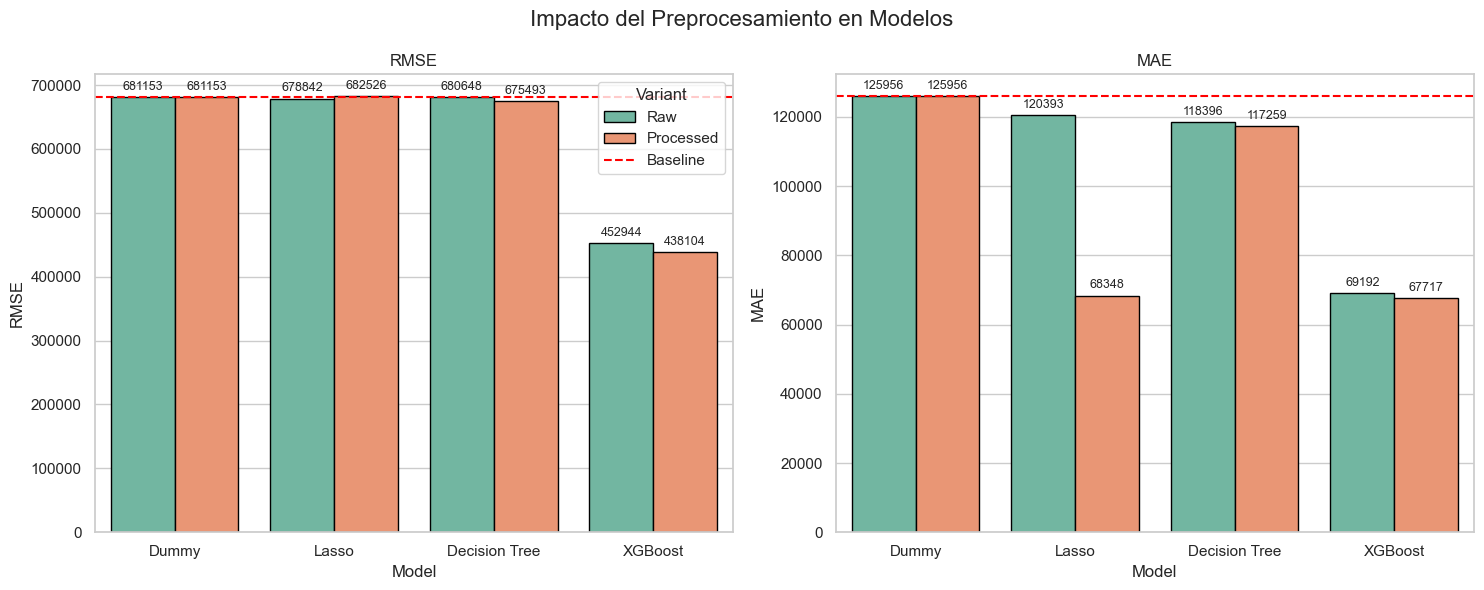

,Model,Variant,RMSE,MAE,R2,MAPE
0,Dummy,Raw,681152.912984,125955.554357,-0.000008,8.174219
1,Dummy,Processed,681152.912984,125955.554357,-0.000008,8.174219
2,Lasso,Raw,678842.275707,120392.781919,0.006765,6.573078
3,Lasso,Processed,682525.505399,68347.977627,-0.004042,0.374194
4,Decision Tree,Raw,680648.205261,118395.757090,0.001473,6.123546
5,Decision Tree,Processed,675493.077691,117259.202317,0.016541,6.020458
6,XGBoost,Raw,452943.740152,69192.130459,0.557816,4.996146
7,XGBoost,Processed,438104.078116,67717.022214,0.586316,4.702945


In [23]:
# Cargamos predicciones de los modelos base para comparar
df_base_preds = pd.read_csv("../predictions/base_models.csv")
y_test_raw = df_base_preds['y_test'].values
y_pred_dummy = df_base_preds['Dummy'].values
y_pred_lasso_raw = df_base_preds['Lasso'].values
y_pred_tree_raw = df_base_preds['Decision Tree'].values
y_pred_xgb_raw = df_base_preds['XGBoost'].values

models_predictions = {
    'model': ['Dummy', 'Lasso', 'Decision Tree', 'XGBoost'],
    'y_pred': [y_pred_dummy, y_pred_lasso_raw, y_pred_tree_raw, y_pred_xgb_raw],
    'y_pred_processed': [y_pred_dummy, y_pred_lasso_p, y_pred_tree_p, y_pred_xgb_p],
    'y_test': y_test_raw,
    'y_test_processed': y_test_p
}
plot_model_comparison(models_predictions)